# Food Delivery Time Prediction
## Objective
Predict food delivery time based on:
- distance
- weather
- traffic
- preparation time
- courier experience

## Business Problem
Late deliveries reduce customer satisfaction.
The goal is to predict delivery time accurately so:
- customers receive realistic ETAs
- logistics can optimize dispatching
- restaurants can improve efficiency

## Dataset Overview

This dataset contains operational and environmental factors affecting food delivery times.

The target variable is:
- `Delivery_Time_min`

The dataset includes:

- Distance-related features 
- Weather conditions
- Traffic congestion
- Time of the Day
- Delivery vehicle information
- Courier experience
- Preparation time

### Import Libraries

In [275]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import squarify
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [276]:
import os
print(os.getcwd())

C:\Users\Ruchita\Imarticus machine learning\ML Projects folder


In [277]:
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Descriptive Analysis

In [278]:
print('='*100)
print('\033[1mShape:\033[0m',df.shape)
print('='*100)
print('\033[1mInfo:\033[0m\n\n ',df.info)
print('='*100)
print('\033[1mDescription:\033[0m\n\n',df.describe())
print('='*100)
print("\033[1mFirst Five Rows:\033[0m\n\n",df.head())
print('='*100)
print("\033[1mLast Five Rows:\033[0m\n\n",df.tail())


Shape: (1000, 9)
Info:

  <bound method DataFrame.info of      Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0         522         7.93   Windy           Low   Afternoon      Scooter   
1         738        16.42   Clear        Medium     Evening         Bike   
2         741         9.52   Foggy           Low       Night      Scooter   
3         661         7.44   Rainy        Medium   Afternoon      Scooter   
4         412        19.03   Clear           Low     Morning         Bike   
..        ...          ...     ...           ...         ...          ...   
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snowy          High     Evening      Scooter   
998       436        14.17   Clear           Low   Afternoon         Bike   
999       103         6.63   Foggy           Low       Night      Scooter   

     Preparation_

### Data Cleaning
    • Missing Values
    • Duplicate Check

In [279]:
df.isna().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [280]:
df[df.duplicated()]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


In [281]:
c = ['Weather','Traffic_Level','Time_of_Day','Courier_Experience_yrs','Vehicle_Type']
for col in c:
    print(col,":" ,df[col].unique())

Weather : ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
Traffic_Level : ['Low' 'Medium' 'High' nan]
Time_of_Day : ['Afternoon' 'Evening' 'Night' 'Morning' nan]
Courier_Experience_yrs : [ 1.  2.  5.  9.  6.  4.  7. nan  3.  8.  0.]
Vehicle_Type : ['Scooter' 'Bike' 'Car']


In [282]:
for col in c:
    print(col,":" ,df[col].mode()[0])

Weather : Clear
Traffic_Level : Medium
Time_of_Day : Morning
Courier_Experience_yrs : 6.0
Vehicle_Type : Bike


In [283]:
for col in c:
    df[col].fillna(df[col].mode()[0],inplace=True)

In [284]:
df.isna().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

# Exploratory Data Analysis

### Univariate Analysis

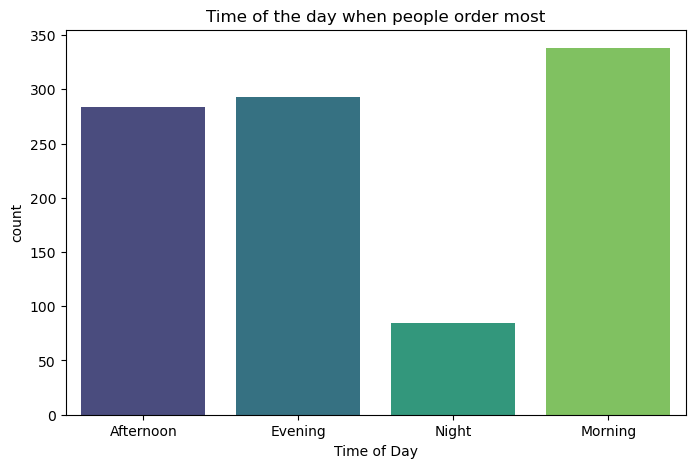

In [285]:
#1. Count Plot
plt.figure(figsize=(8,5))
sns.countplot(palette='viridis',data = df, x ='Time_of_Day')
plt.title('Time of the day when people order most')
plt.xlabel('Time of Day')
plt.show()

##### Insights:  
Morning time has the highest number of food orders, followed closely by evening and afternoon periods, while night orders are significantly lower.

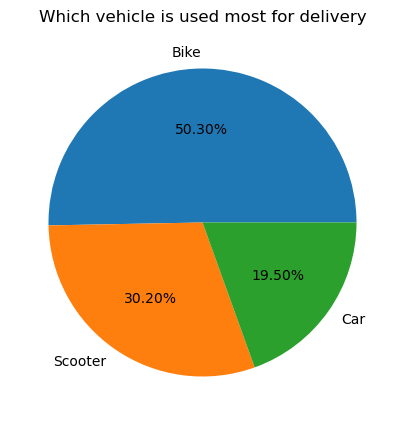

In [286]:
# 2. Piechart
plt.figure(figsize=(8,5))
df['Vehicle_Type'].value_counts().plot(kind='pie',autopct='%.2f%%')
plt.ylabel('')
plt.title('Which vehicle is used most for delivery')
plt.show()

##### Insights:
Bikes account for more than 50% of deliveries, making them the dominant transportation mode. Scooters contribute around 30%, while cars are used least frequently.

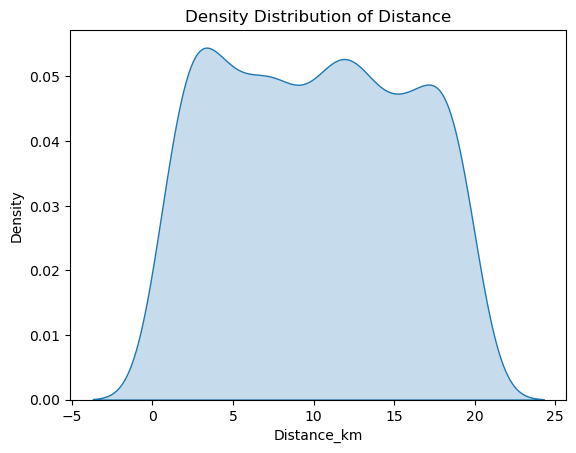

In [287]:
#3. Density Plot
sns.kdeplot(data = df,x='Distance_km',fill=True )
plt.title('Density Distribution of Distance')
plt.show()

##### Insights:
Delivery distances are distributed across short to medium ranges, with most orders concentrated between approximately 3 km and 20 km.

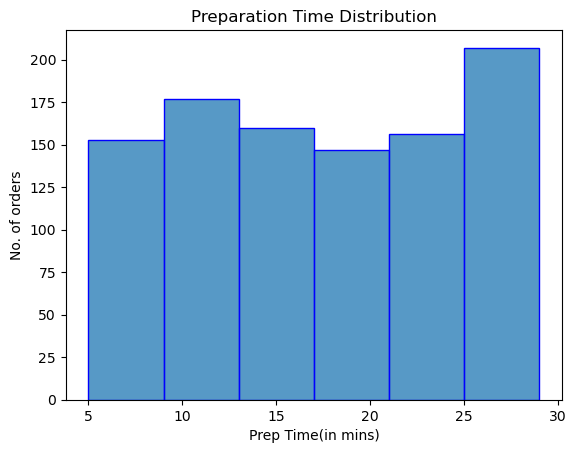

In [288]:
# 4. Histogram 
sns.histplot(data=df,x='Preparation_Time_min',bins=6,edgecolor='Blue')
plt.xlabel('Prep Time(in mins)')
plt.title('Preparation Time Distribution')
plt.ylabel('No. of orders')
plt.show()

##### Insights:
Preparation times are moderately distributed between 5 and 30 minutes, with a slightly higher concentration toward the upper preparation range.

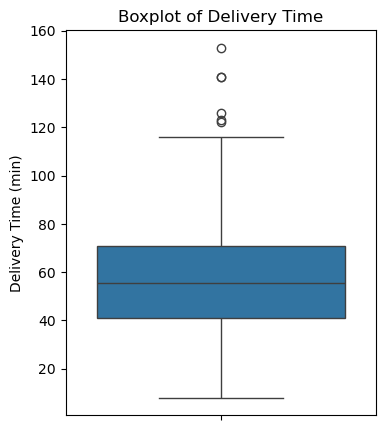

In [289]:
# 5. Box Plot(For outliers)
plt.figure(figsize=(4,5))
sns.boxplot(data=df,y='Delivery_Time_min')
plt.title('Boxplot of Delivery Time')
plt.ylabel('Delivery Time (min)')
plt.show()

### Bivariate Analysis

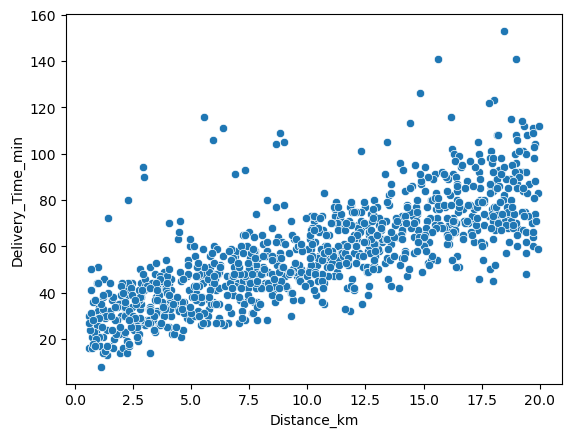

In [290]:
# Scatter Plot
sns.scatterplot(data=df,y='Delivery_Time_min',x='Distance_km',)
plt.show()

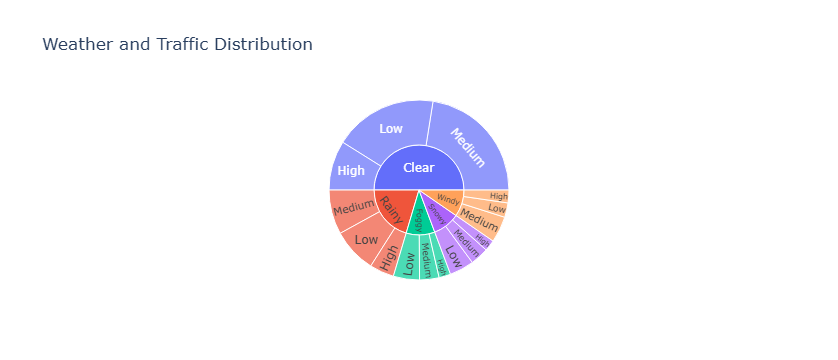

<Figure size 2000x1000 with 0 Axes>

In [291]:
# Sunburst 
plt.figure(figsize=(20,10))
fig = px.sunburst(
    df,
    path=[ 'Weather','Traffic_Level'],
    title='Weather and Traffic Distribution'
)

fig.show()

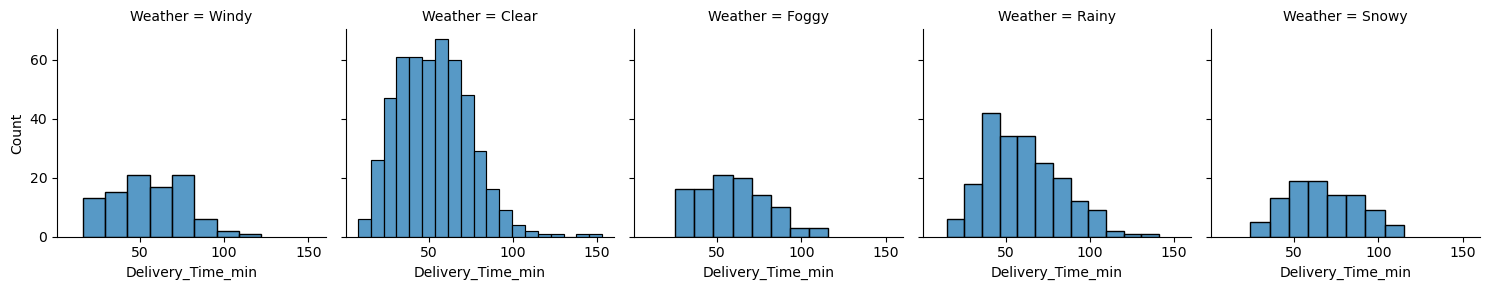

In [292]:
# Facetgrid
g = sns.FacetGrid(df, col='Weather')
g.map(sns.histplot, 'Delivery_Time_min')
plt.show()

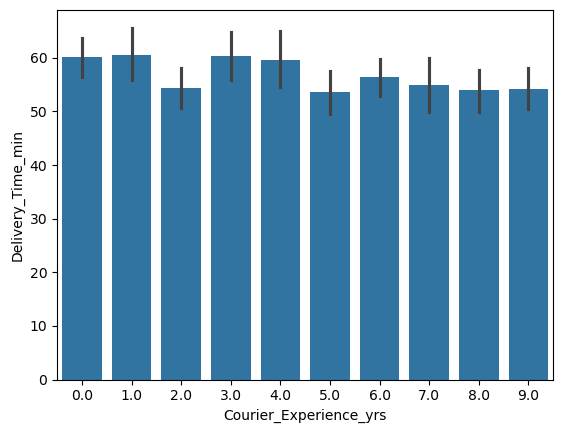

In [293]:
sns.barplot(x='Courier_Experience_yrs',y='Delivery_Time_min',data=df)
plt.show()

### Multivariate Analysis

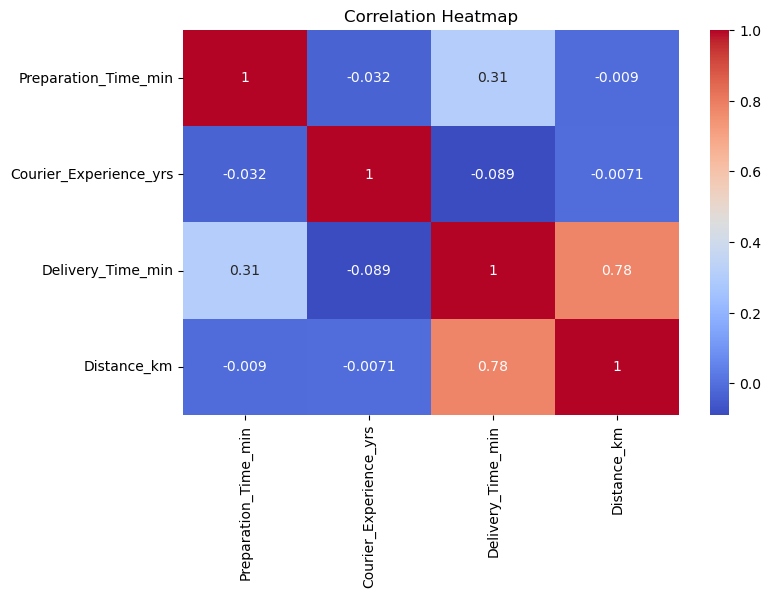

In [294]:
plt.figure(figsize=(8,5))
corr = df[['Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min','Distance_km']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

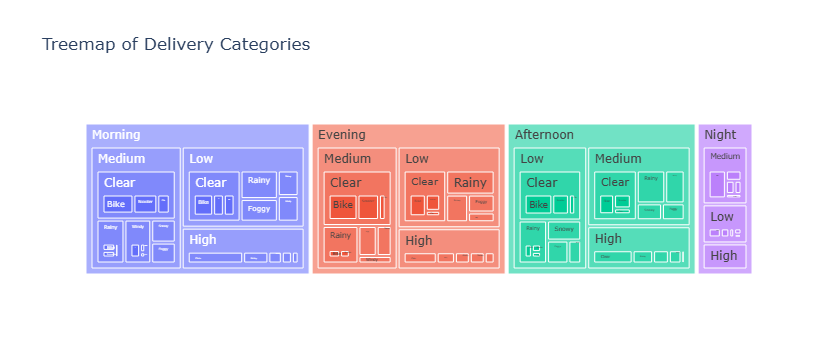

In [295]:
fig = px.treemap(df,path=['Time_of_Day','Traffic_Level','Weather','Vehicle_Type'],title='Treemap of Delivery Categories')

fig.show()

# Statistical test 

In [296]:
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [297]:
from scipy import stats
import statistics as stat

# Checking if Vehicle Type have any affect on delivery time.
"""By One way Anova  we will test which categorical group have significant difference in deliveery time
where Null Hypothesis --> There is NO Significant difference in the mean of the group
      Alternative Hypothesis --> There is at least one group  that show significant difference from the other two"""

Scooter = df[df['Vehicle_Type'] == 'Scooter']['Delivery_Time_min'].tolist()
Bike = df[df['Vehicle_Type'] == 'Bike']['Delivery_Time_min'].tolist()
Car = df[df['Vehicle_Type'] == 'Car']['Delivery_Time_min'].tolist()

print('Scooter mean: ',np.mean(Scooter))
print('Bike mean: ',np.mean(Bike))
print('Car mean: ',np.mean(Car))

Scooter mean:  56.04635761589404
Bike mean:  56.57455268389662
Car mean:  58.2


In [298]:
stats.f_oneway(Scooter,Bike,Car)

F_onewayResult(statistic=np.float64(0.5893743449801336), pvalue=np.float64(0.554867344896123))

**P_value >0.05, Therefore we fail to reject Null Hypothesis i.e, there is no significant difference in delivery time w.r.t vehicle can also see in means of vehicle type.**

In [299]:
# Checking if Traffic_Level have any affect on delivery time.
low  = df[df['Traffic_Level'] == 'Low']['Delivery_Time_min'].tolist()
medium = df[df['Traffic_Level'] == 'Medium']['Delivery_Time_min'].tolist()
high = df[df['Traffic_Level'] == 'High']['Delivery_Time_min'].tolist()


In [300]:
stats.f_oneway(low,medium,high)

F_onewayResult(statistic=np.float64(19.7513383477373), pvalue=np.float64(3.86970694692821e-09))

p_value <0.05, therefor we reject Null Hypothesis i.e,There is at least one group  that show significant difference from the other two.
To check which group cause this difference we will use    
Post-Hoc Test --> Tukey's HSD Test

In [301]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
data = low + medium + high
labels = (
    ['low']*len(low)+
    ['medium']*len(medium)+
    ['high']*len(high)
)
tukey = pairwise_tukeyhsd(data,labels)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  high    low  -11.922    0.0 -16.3811 -7.4628   True
  high medium  -8.3547    0.0 -12.7467 -3.9628   True
   low medium   3.5673 0.0522  -0.0261  7.1607  False
-----------------------------------------------------


Traffic level affects delivery time mainly because:
- **High traffic** causes significantly **longer deliveries**
- But Low and Medium traffic are not significantly different from each other

In [302]:
# Checking if Weather have any affect on delivery time.
print(df.Weather.unique())
Windy  = df[df['Weather'] == 'Windy']['Delivery_Time_min'].tolist()
Clear = df[df['Weather'] == 'Clear']['Delivery_Time_min'].tolist()
Foggy = df[df['Weather'] == 'Foggy']['Delivery_Time_min'].tolist()
Rainy = df[df['Weather'] == 'Rainy']['Delivery_Time_min'].tolist()
Snowy = df[df['Weather'] == 'Snowy']['Delivery_Time_min'].tolist()

['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy']


In [303]:
stats.f_oneway(Windy,Clear,Foggy,Rainy,Snowy)

F_onewayResult(statistic=np.float64(10.499059475928277), pvalue=np.float64(2.472288388818336e-08))

p_value <0.05, therefor we reject Null Hypothesis i.e,There is at least one group  that show significant difference from the other two.
To check which group cause this difference we will use    
Post-Hoc Test --> Tukey's HSD Test

In [ ]:
data = Windy+Clear+Foggy+Rainy+Snowy
labels = (
    ['Windy']*len(Windy)+
    ['Clear']*len(Clear)+
    ['Foggy']*len(Foggy)+
    ['Rainy']*len(Rainy)+
    ['Snowy']*len(Snowy)
)
tukey = pairwise_tukeyhsd(data,labels)
print(tukey)

The main finding is:  
Snowy weather significantly increases delivery times compared to most other weather conditions.  
Rainy weather also increases delivery time compared to clear weather, but the effect is smaller.  
Foggy and windy conditions do not show strong statistical differences from most other groups.  

## Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder 
from sklearn.linear_model import Lasso,Ridge,ElasticNet

In [ ]:
df.columns

In [ ]:
# OneHotEncoder Using Scikit Library
cat_col = df.select_dtypes(include=['object']).columns.tolist()
cat_col

In [ ]:
encoder = OneHotEncoder(sparse_output = False)
onehot_encoder = encoder.fit_transform(df[cat_col])
onehot_df = pd.DataFrame(onehot_encoder,columns=encoder.get_feature_names_out(cat_col))
df_encoded = pd.concat([df, onehot_df],axis=1)
df_encoded = df_encoded.drop(cat_col,axis=1)
df_encoded

In [ ]:
x = df_encoded.drop(['Delivery_Time_min', 'Order_ID'], axis=1)
y = df_encoded['Delivery_Time_min']

In [ ]:
x

In [ ]:
y

### Train size =80% and Test size =20%

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.80, random_state = 42)

In [ ]:
x_train

In [ ]:
lr= LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
r2=r2_score(y_test,y_pred)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test,y_pred)
print('mae: ',mae)
mse = mean_squared_error(y_test,y_pred)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test,y_pred)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test,y_pred)
print('mape: ',mape*100)


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
l1 = Lasso()

In [ ]:
l1.fit(x_train,y_train)

In [ ]:
y_pred1=l1.predict(x_test)
y_pred1

In [ ]:
r2=r2_score(y_test,y_pred1)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test,y_pred1)
print('mae: ',mae)
mse = mean_squared_error(y_test,y_pred1)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test,y_pred1)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test,y_pred1)
print('mape: ',mape*100)

In [ ]:
l2=Ridge()

In [ ]:
l2.fit(x_train,y_train)

In [ ]:
y_pred2=l2.predict(x_test)

In [ ]:
r2=r2_score(y_test,y_pred2)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test,y_pred2)
print('mae: ',mae)
mse = mean_squared_error(y_test,y_pred2)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test,y_pred2)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test,y_pred2)
print('mape: ',mape*100)

In [ ]:
l12 = ElasticNet()

In [ ]:
l12.fit(x_train,y_train)

In [ ]:
y_pred12=l12.predict(x_test)

In [ ]:
r2=r2_score(y_test,y_pred12)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test,y_pred12)
print('mae: ',mae)
mse = mean_squared_error(y_test,y_pred12)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test,y_pred12)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test,y_pred12)
print('mape: ',mape*100)

### Train size =70% and Test size =30%

In [ ]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x,y, train_size=0.70, random_state = 42)

In [ ]:
lr1= LinearRegression()
lr1.fit(x_train1,y_train1)

In [ ]:
y_predi1 = lr1.predict(x_test1)

In [ ]:
r2=r2_score(y_test1,y_predi1)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test1,y_predi1)
print('mae: ',mae)
mse = mean_squared_error(y_test1,y_predi1)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test1,y_predi1)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test1,y_predi1)
print('mape: ',mape*100)

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test1, y_predi1)
plt.plot([y_test1.min(), y_test1.max()],
         [y_test1.min(), y_test1.max()],
         'r--')
plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [ ]:
residuals = y_test1 - y_predi1

plt.figure(figsize=(8,5))
plt.scatter(y_predi1, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
lr1= Lasso()
lr1.fit(x_train1,y_train1)

In [ ]:
y_predi1 = lr1.predict(x_test1)

In [ ]:
r2=r2_score(y_test1,y_predi1)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test1,y_predi1)
print('mae: ',mae)
mse = mean_squared_error(y_test1,y_predi1)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test1,y_predi1)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test1,y_predi1)
print('mape: ',mape*100)

In [ ]:
lr2 = Ridge()
lr2.fit(x_train1,y_train1)

In [ ]:
y_predi2 = lr2.predict(x_test1)

In [ ]:
r2=r2_score(y_test1,y_predi2)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test1,y_predi2)
print('mae: ',mae)
mse = mean_squared_error(y_test1,y_predi2)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test1,y_predi2)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test1,y_predi2)
print('mape: ',mape*100)

In [ ]:
lr12 = ElasticNet()
lr12.fit(x_train1,y_train1)

In [ ]:
y_predi12 = lr12.predict(x_test1)

In [ ]:
r2=r2_score(y_test1,y_predi12)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test1,y_predi12)
print('mae: ',mae)
mse = mean_squared_error(y_test1,y_predi12)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test1,y_predi12)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test1,y_predi12)
print('mape: ',mape*100)

### Train size = 60% and Test size = 40%

In [ ]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x,y, train_size=0.60, random_state = 42)

In [ ]:
lre= LinearRegression()
lre.fit(x_train2,y_train2)

In [ ]:
y_predic = lre.predict(x_test2)

In [ ]:
r2=r2_score(y_test2,y_predic)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test2,y_predic)
print('mae: ',mae)
mse = mean_squared_error(y_test2,y_predic)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test2,y_predic)
print('rmse: ',rmse)

mape = mean_absolute_percentage_error(y_test2,y_predic)
print('mape: ',mape*100)

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test2, y_predic)
plt.plot([y_test2.min(), y_test2.max()],
         [y_test2.min(), y_test2.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [ ]:
residuals = y_test2 - y_predic

plt.figure(figsize=(8,5))
plt.scatter(y_predic, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show

In [ ]:
lre1 = Lasso()
lre1.fit(x_train2,y_train2)

In [ ]:
y_predic1 = lre1.predict(x_test2)

In [ ]:
r2=r2_score(y_test2,y_predic1)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test2,y_predic1)
print('mae: ',mae)
mse = mean_squared_error(y_test2,y_predic1)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test2,y_predic1)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test2,y_predic1)
print('mape: ',mape*100)

In [ ]:
lre2 = Ridge()
lre2.fit(x_train2,y_train2)

In [ ]:
y_predic2 = lre2.predict(x_test2)

In [ ]:
r2=r2_score(y_test2,y_predic2)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test2,y_predic2)
print('mae: ',mae)
mse = mean_squared_error(y_test2,y_predic2)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test2,y_predic2)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test2,y_predic2)
print('mape: ',mape*100)

In [ ]:
lre12 = ElasticNet()
lre12.fit(x_train2,y_train2)

In [ ]:
y_predic12 = lre12.predict(x_test2)

In [ ]:
r2=r2_score(y_test2,y_predic12)
print("r2 score :",r2*100)
mae = mean_absolute_error(y_test2,y_predic12)
print('mae: ',mae)
mse = mean_squared_error(y_test2,y_predic12)
print("mse: ",mse)
rmse = root_mean_squared_error(y_test2,y_predic12)
print('rmse: ',rmse)
mape = mean_absolute_percentage_error(y_test2,y_predic12)
print('mape: ',mape*100)

## Model Performance Comparison

| Train-Test Split | Model | R² Score (%) | MAE | MSE | RMSE | MAPE (%) |
|---|---|---:|---:|---:|---:|---:|
| 80/20 | Linear Regression | 82.59 | 5.91 | 78.06 | 8.84 | 10.41 |
| 80/20 | Lasso | 76.83 | 7.02 | 103.83 | 10.19 | 13.42 |
| 80/20 | Ridge | 82.46 | 5.92 | 78.64 | 8.87 | 10.44 |
| 80/20 | ElasticNet | 76.24 | 7.12 | 106.52 | 10.32 | 13.71 |
| 70/30 | Linear Regression | **83.23** | **6.06** | **84.95** | **9.22** | **10.62** |
| 70/30 | Lasso | 79.26 | 6.92 | 103.84 | 10.19 | 13.32 |
| 70/30 | Ridge | 83.03 | 6.06 | 84.97 | 9.22 | 10.62 |
| 70/30 | ElasticNet | 78.60 | 7.05 | 107.15 | 10.35 | 13.70 |
| 60/40 | Linear Regression | 76.15 | 6.79 | 117.23 | 10.83 | 11.43 |
| 60/40 | Lasso | 70.93 | 7.73 | 142.92 | 11.95 | 13.99 |
| 60/40 | Ridge | 76.14 | 6.79 | 117.30 | 10.83 | 11.43 |
| 60/40 | ElasticNet | 70.92 | 7.73 | 142.96 | 11.96 | 14.03 |

### Test Prediction on New Data

In [ ]:
# New order for prediction

new_order = pd.DataFrame({
    'Distance_km': [8.5],
    'Weather': ['Clear'],
    'Traffic_Level': ['Medium'],
    'Time_of_Day': ['Evening'],
    'Vehicle_Type': ['Scooter'],
    'Preparation_Time_min': [15],
    'Courier_Experience_yrs': [4]
})

# Encode categorical columns
new_order_encoded = encoder.transform(new_order[cat_col])

new_order_encoded_df = pd.DataFrame(
    new_order_encoded,
    columns=encoder.get_feature_names_out(cat_col)
)

new_order_final = pd.concat(
    [new_order.drop(cat_col, axis=1).reset_index(drop=True),
     new_order_encoded_df],
    axis=1
)

# Prediction
predicted_time = lr1.predict(new_order_final)

print("Predicted Delivery Time:", round(predicted_time[0], 2), "minutes")

## Conclusion

Linear Regression (70/30 split) achieved the best overall performance among the tested models.
The model can predict food delivery time based on distance, weather, traffic level, time of day, vehicle type, preparation time, and courier experience.
For a sample new order, the model predicted a delivery time of approximately **50.49minutes**.